# S-Fig 4 — Task Landscape

Panel (a): scatter — task difficulty vs context sensitivity.  
Panel (b): lollipop — saturation context L* per task.  
**Source**: analysis.csv (k=all)  
**Tasks**: all tasks

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
TASKS  = ALL_TASKS
HEADS  = ["lstm", "transformer"]
SPLIT  = "test"

df = load_analysis("phase0_v3", split=SPLIT, k="all")

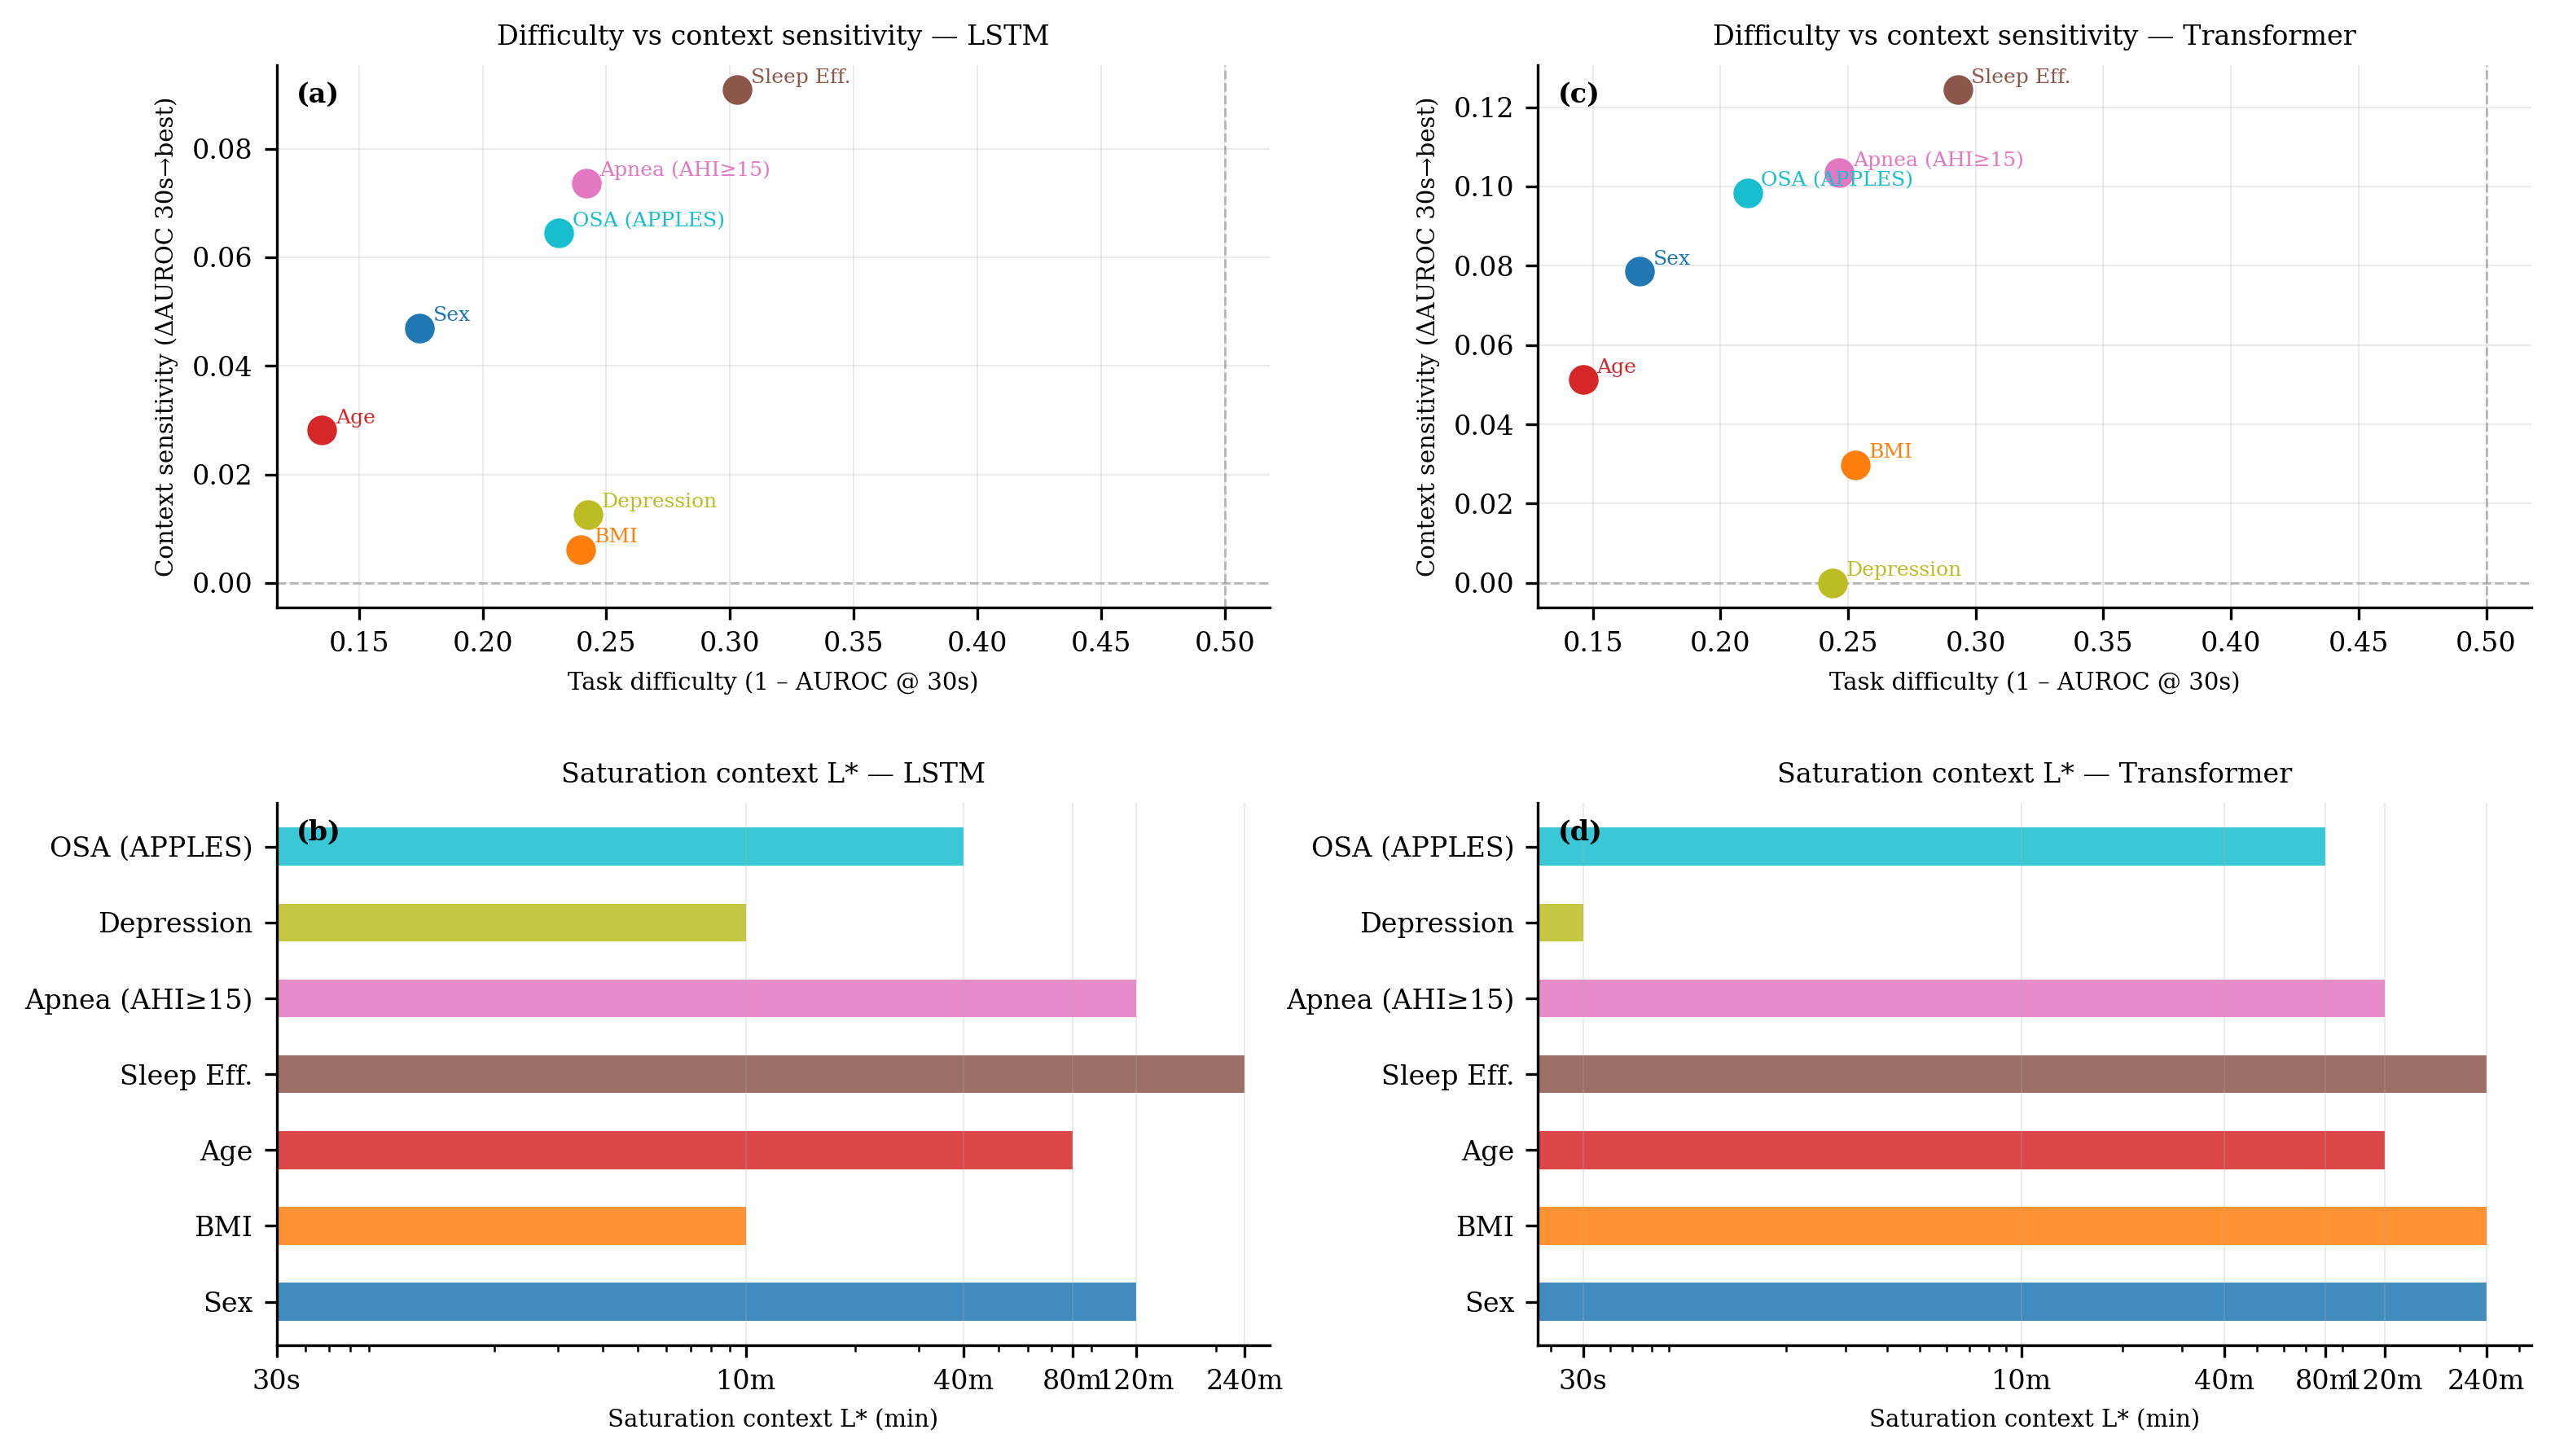

In [11]:
_HEAD_LABEL = {h: HEAD_STYLE[h]["label"] for h in HEADS}
_panel_labels = iter("abcd")

fig, axes = plt.subplots(2, 2, figsize=(FULL_W+3.5, 6.0))

for col, head in enumerate(HEADS):
    panels.task_scatter_panel(axes[0, col], df, tasks=TASKS, head=head)
    add_panel_label(axes[0, col], f"({next(_panel_labels)})")
    axes[0, col].set_title(
        f"Difficulty vs context sensitivity — {_HEAD_LABEL[head]}", fontsize=FONT_TITLE)

    panels.lstar_panel(axes[1, col], df, tasks=TASKS, head=head, tol=0.005)
    add_panel_label(axes[1, col], f"({next(_panel_labels)})")
    axes[1, col].set_title(
        f"Saturation context L* — {_HEAD_LABEL[head]}", fontsize=FONT_TITLE)

fig.tight_layout(h_pad=2.5, w_pad=0.0)
plt.show()

In [12]:
save_figure(fig, FINAL_OUT, "sfig10_task_landscape")
import shutil
shutil.copy(FINAL_OUT / "sfig10_task_landscape.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig10_task_landscape.pdf")
print("Saved + copied → TBME_submission/sfig10_task_landscape.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig10_task_landscape.pdf
Saved + copied → TBME_submission/sfig10_task_landscape.pdf
